<a href="https://colab.research.google.com/github/SesSic/IAInvestigacionCurso/blob/main/sesion-05-visualizacion/sesion05_completo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 5 — Visualización y comunicación científica

**Temas:** selección de gráficos, Matplotlib, construcción, personalización y exportación de figuras

**Duración:** 3 horas

## Objetivo de la sesión
- Elegir el tipo de gráfico correcto según lo que quieres mostrar
- Construir y personalizar gráficos con Matplotlib (títulos, ejes, colores, leyenda)
- Exportar figuras en calidad de publicación, listas para un informe o artículo

> 💡 Esto reemplaza lo que haces en Excel/Origin/GraphPad para generar gráficos — con más control y sin límite de licencia.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
url = "https://raw.githubusercontent.com/SesSic/IAInvestigacionCurso/main/datasets/ejemplo_notas.csv"
datos = pd.read_csv(url)
datos.head()

,estudiante,facultad,grupo,nota_parcial1,nota_parcial2,asistencia_pct
0,Ana Torres,Ciencias Sociales,A,7.5,8.2,95
1,Luis Paredes,Ingeniería,A,6.8,7.0,80
2,Maria Chango,Ciencias Sociales,B,8.9,9.1,100
3,Carlos Vega,Educación,B,5.5,6.2,70
4,Sofia Ramos,Ingeniería,A,9.0,9.4,98


---## 🟦 Bloque 1 (50 min) — Elegir y construir el gráfico correcto

### 1.1 ¿Qué gráfico uso según lo que quiero mostrar?
| Quiero mostrar... | Uso este gráfico |
|---|---|
| Comparar un valor entre categorías (ej. promedio por facultad) | Barras |
| Relación entre dos variables numéricas | Dispersión (scatter) |
| Distribución y valores atípicos de una variable | Caja (boxplot) |
| Evolución en el tiempo | Línea |

### 1.2 Gráfico de barras: promedio por grupo

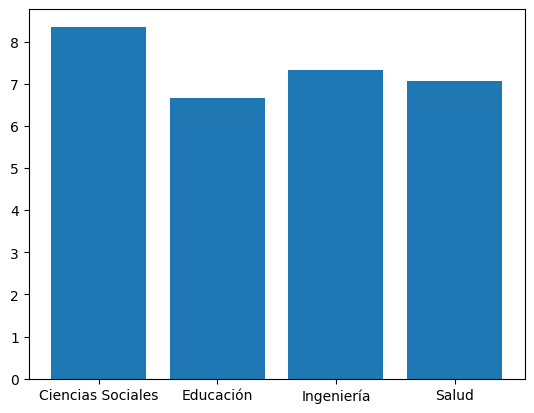

In [3]:
promedio_facultad = datos.groupby("facultad")["nota_parcial1"].mean()
plt.bar(promedio_facultad.index, promedio_facultad.values)
plt.show()

### 1.3 Gráfico de dispersión: relación entre dos variables

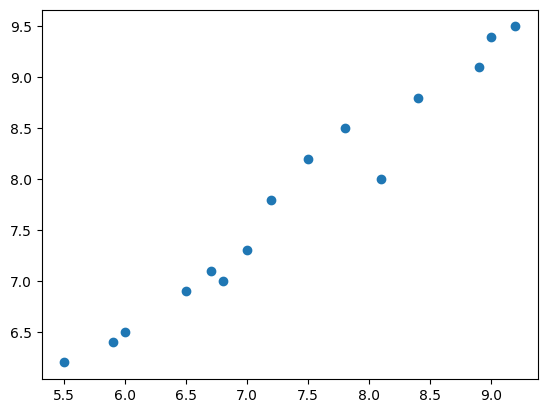

In [4]:
plt.scatter(datos["nota_parcial1"], datos["nota_parcial2"])
plt.show()

---### 🧪 Ejercicio 1 — Grafica tu propia base

Con tu dataset (o el de tu área), haz un gráfico de barras del promedio por grupo o facultad.

In [ ]:
# Tu gráfico de barras aquí

---## ☕ Descanso — 15 minutos

---## 🟩 Bloque 2 (50 min) — Personalización: títulos, ejes, colores, leyenda

### 2.1 Un gráfico "desnudo" no sirve para un informe

Sin título ni ejes etiquetados, nadie más que tú entiende qué representa. Vamos a vestirlo correctamente.

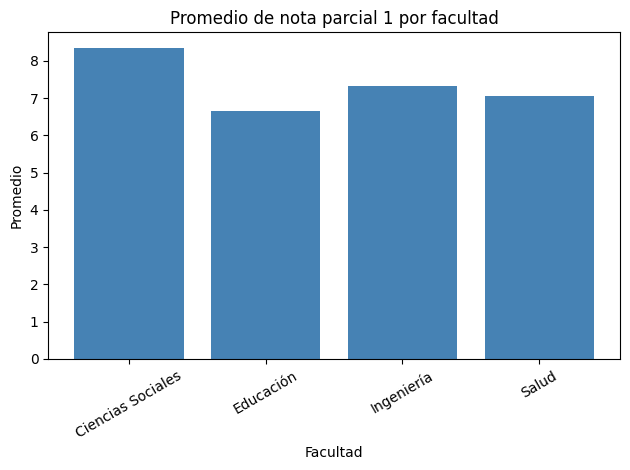

In [5]:
promedio_facultad = datos.groupby("facultad")["nota_parcial1"].mean()
plt.bar(promedio_facultad.index, promedio_facultad.values, color="steelblue")
plt.title("Promedio de nota parcial 1 por facultad")
plt.xlabel("Facultad")
plt.ylabel("Promedio")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 2.2 Comparar dos series con leyenda

Útil para mostrar, por ejemplo, `nota_parcial1` vs `nota_parcial2` por facultad, uno al lado del otro.

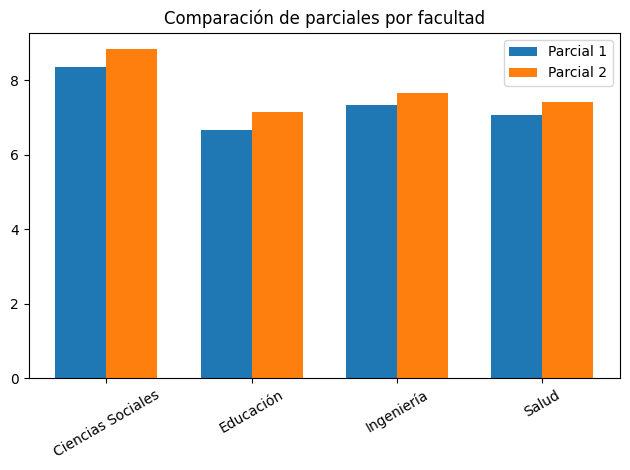

In [6]:
resumen = datos.groupby("facultad")[["nota_parcial1", "nota_parcial2"]].mean()
x = range(len(resumen))
ancho = 0.35
plt.bar([i - ancho/2 for i in x], resumen["nota_parcial1"], width=ancho, label="Parcial 1")
plt.bar([i + ancho/2 for i in x], resumen["nota_parcial2"], width=ancho, label="Parcial 2")
plt.xticks(list(x), resumen.index, rotation=30)
plt.legend()
plt.title("Comparación de parciales por facultad")
plt.tight_layout()
plt.show()

### 2.3 Boxplot: distribución y valores atípicos por grupo

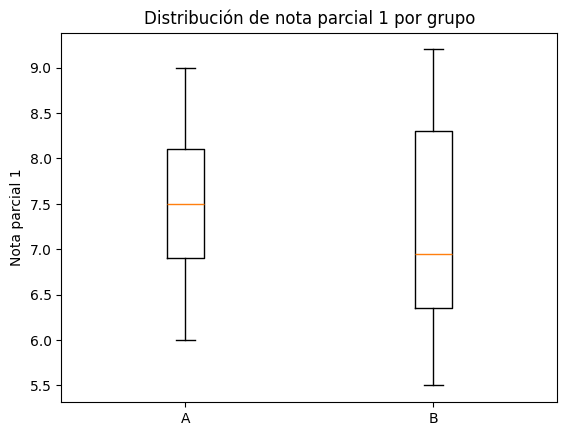

In [8]:
grupos_datos = [grupo["nota_parcial1"].values for nombre, grupo in datos.groupby("grupo")]
etiquetas = datos["grupo"].unique()
plt.boxplot(grupos_datos, tick_labels=etiquetas)
plt.title("Distribución de nota parcial 1 por grupo")
plt.ylabel("Nota parcial 1")
plt.show()

---### 🧪 Ejercicio 2 — Personaliza un gráfico con tus datos

Toma el gráfico de barras del Ejercicio 1 y agrégale título, etiquetas de eje y color.

In [ ]:
# Tu gráfico personalizado aquí

---## ☕ Descanso — 15 minutos

---## 🟨 Bloque 3 (50 min) — Exportar en calidad de publicación y cierre

### 3.1 Guardar la figura como archivo`dpi=300` es el estándar mínimo que piden la mayoría de revistas científicas para figuras.

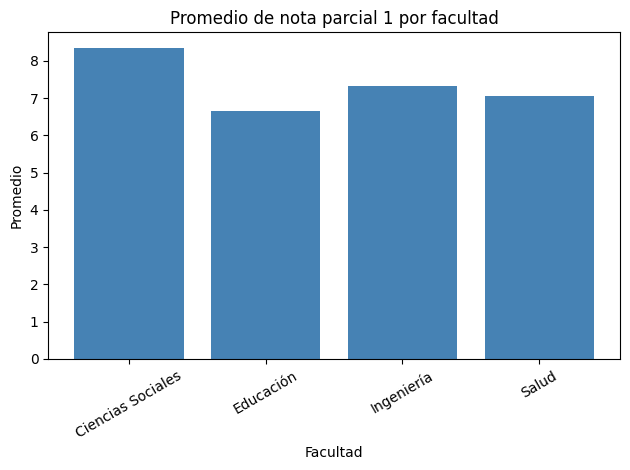

Archivo guardado. Búscalo en el panel de archivos de la izquierda (ícono de carpeta 📁).


In [9]:
promedio_facultad = datos.groupby("facultad")["nota_parcial1"].mean()
plt.bar(promedio_facultad.index, promedio_facultad.values, color="steelblue")
plt.title("Promedio de nota parcial 1 por facultad")
plt.xlabel("Facultad")
plt.ylabel("Promedio")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("grafico_promedio_facultad.png", dpi=300)
plt.show()
print("Archivo guardado. Búscalo en el panel de archivos de la izquierda (ícono de carpeta 📁).")

### 3.2 Formatos según el uso
| Formato | Cuándo usarlo |
|---|---|
| PNG | Informes, presentaciones, Word |
| SVG | Cuando necesitas editar el gráfico después en otro programa (escalable sin perder calidad) |
| PDF | Publicaciones académicas (algunas revistas lo piden) |

Solo cambia la extensión en `plt.savefig("grafico.svg")` o `plt.savefig("grafico.pdf")`.

---### 🧪 Ejercicio final — Tu figura lista para publicación

Toma cualquier gráfico que hiciste hoy con tus propios datos, agrégale título y etiquetas, y expórtalo en PNG a 300 dpi.

In [ ]:
# Tu figura final, lista para exportar

---## ✅ Cierre de la sesiónHoy lograste:
- ✅ Elegir el tipo de gráfico correcto según el mensaje que quieres dar
- ✅ Construir barras, dispersión y boxplots
- ✅ Personalizar títulos, etiquetas, colores y leyendas
- ✅ Exportar en calidad de publicación (300 dpi)

**Para la próxima sesión (IA generativa):** vamos a usar IA para acelerar tareas de programación e investigación — incluyendo un ejercicio práctico con sílabos.

📎 Recuerda: `Archivo → Guardar una copia en Drive` para no perder tu trabajo.